# 01 Project Setup

## Project question

Where might physical climate exposure be concentrated across UK renewable energy infrastructure?

## What this project is

This project is a Version 1 geospatial exposure-screening model. It uses public renewable energy asset data to demonstrate how infrastructure assets can be cleaned, mapped, scored and summarised for physical climate risk review.

## What this project is not

This is not a production catastrophe model. It does not estimate financial loss, probability of asset failure, insured loss or engineering damage.

The first version focuses on UK renewable energy assets. Future versions could add transport infrastructure, formal flood zones, heat stress layers, coastal erosion data and asset value estimates.

## Notebook goal

This notebook checks the project folder structure, confirms the Python environment, and inspects the raw asset dataset.

In [211]:
from pathlib import Path

import pandas as pd
import geopandas as gpd

PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
MAPS = OUTPUTS / "maps"

for folder in [DATA_RAW, DATA_INTERIM, DATA_PROCESSED, FIGURES, TABLES, MAPS]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_RAW)
print("Processed data folder:", DATA_PROCESSED)

Project root: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy
Raw data folder: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/raw
Processed data folder: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed


In [212]:
from pathlib import Path
import pandas as pd
import os

DATA_RAW = Path("/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/raw")

print("DATA_RAW path:")
print(DATA_RAW)

print("\nDoes this folder exist?")
print(DATA_RAW.exists())

print("\nFiles using os.listdir:")
print(os.listdir(DATA_RAW))

print("\nCSV files using glob:")
print(list(DATA_RAW.glob("*.csv")))

DATA_RAW path:
/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/raw

Does this folder exist?
True

Files using os.listdir:
['repd_publication_q4_2025_raw.csv']

CSV files using glob:
[PosixPath('/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/raw/repd_publication_q4_2025_raw.csv')]


In [213]:
from pathlib import Path
import pandas as pd
import os

DATA_RAW = Path("/Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/raw")

csv_files = list(DATA_RAW.glob("*.csv"))
raw_asset_file = csv_files[0]

print("Using:", raw_asset_file.name)

df_raw = pd.read_csv(raw_asset_file, encoding="latin1")

print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

df_raw.head()

Using: repd_publication_q4_2025_raw.csv
Rows: 13995
Columns: 53


,Old Ref ID,Ref ID,Record Last Updated (dd/mm/yyyy),Operator (or Applicant),Site Name,Technology Type,Storage Type,Storage Co-location REPD Ref ID,Installed Capacity (MWelec),Share Community Scheme,...,Appeal Granted,Planning Permission Granted,Secretary of State - Intervened,Secretary of State - Refusal,Secretary of State - Granted,Planning Permission Expired,Under Construction,Operational,Heat Network Ref,Solar Site Area (sqm)
0,N00053B,1,16/01/2026,RWE npower,Aberthaw Power Station Biomass,Biomass (co-firing),NaN,NaN,35.00,NaN,...,NaN,03/09/2004,NaN,NaN,NaN,NaN,01/05/2006,01/05/2007,NaN,NaN
1,AA110,2,20/11/2017,Orsted (formerly Dong Energy) / Peel Energy,Hunterston - cofiring,Biomass (co-firing),NaN,NaN,170.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B0730,3,20/12/2019,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,NaN,NaN,70.00,NaN,...,NaN,28/10/2015,NaN,NaN,NaN,28/10/2020,01/09/2016,20/12/2019,NaN,NaN
3,1106000,4,18/12/2003,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),NaN,NaN,38.50,NaN,...,NaN,05/05/1995,NaN,NaN,NaN,NaN,NaN,02/10/1998,NaN,NaN
4,,5,29/09/2005,Agrigen,Nunn Mills Road Biomass Plant,Biomass (dedicated),NaN,NaN,8.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [214]:
df_raw.columns.tolist()

['Old Ref ID',
 'Ref ID',
 'Record Last Updated (dd/mm/yyyy)',
 'Operator (or Applicant)',
 'Site Name',
 'Technology Type',
 'Storage Type',
 'Storage Co-location REPD Ref ID',
 'Installed Capacity (MWelec)',
 'Share Community Scheme',
 'CHP Enabled',
 'CfD Allocation Round',
 'RO Banding (ROC/MWh)',
 'FiT Tariff (p/kWh)',
 'CfD Capacity (MW)',
 'Turbine Capacity (MW)',
 'No. of Turbines',
 'Height of Turbines (m)',
 'Mounting Type for Solar',
 'Development Status',
 'Development Status (short)',
 'Are they re-applying (New REPD Ref)',
 'Are they re-applying (Old REPD Ref) ',
 'Address',
 'County',
 'Region',
 'Country',
 'Post Code',
 'X-coordinate',
 'Y-coordinate',
 'Planning Authority',
 'Planning Application Reference',
 'Appeal Reference',
 'Secretary of State Reference',
 'Type of Secretary of State Intervention',
 'Judicial Review',
 'Offshore Wind Round',
 'Planning Application Submitted',
 'Planning Application Withdrawn',
 'Planning Permission Refused',
 'Appeal Lodged',
 '

In [215]:
for i, col in enumerate(df_raw.columns):
    print(i, col)

0 Old Ref ID
1 Ref ID
2 Record Last Updated (dd/mm/yyyy)
3 Operator (or Applicant)
4 Site Name
5 Technology Type
6 Storage Type
7 Storage Co-location REPD Ref ID
8 Installed Capacity (MWelec)
9 Share Community Scheme
10 CHP Enabled
11 CfD Allocation Round
12 RO Banding (ROC/MWh)
13 FiT Tariff (p/kWh)
14 CfD Capacity (MW)
15 Turbine Capacity (MW)
16 No. of Turbines
17 Height of Turbines (m)
18 Mounting Type for Solar
19 Development Status
20 Development Status (short)
21 Are they re-applying (New REPD Ref)
22 Are they re-applying (Old REPD Ref) 
23 Address
24 County
25 Region
26 Country
27 Post Code
28 X-coordinate
29 Y-coordinate
30 Planning Authority
31 Planning Application Reference
32 Appeal Reference
33 Secretary of State Reference
34 Type of Secretary of State Intervention
35 Judicial Review
36 Offshore Wind Round
37 Planning Application Submitted
38 Planning Application Withdrawn
39 Planning Permission Refused
40 Appeal Lodged
41 Appeal Withdrawn
42 Appeal Refused
43 Appeal Grant

## Column selection logic

The raw REPD dataset contains 53 columns covering project identifiers, planning status, technology type, capacity, location and planning history.

For this Version 1 exposure-screening project, I keep the columns needed to answer four questions:

1. What is the asset?
2. What type of technology is it?
3. Is it operational?
4. Where is it located?

I also keep installed capacity because it can be used as a simple proxy for asset scale. Planning appeal and legal-status columns are excluded from the first version because the project is focused on physical exposure screening rather than planning policy analysis.

In [216]:
useful_columns = [
    "Ref ID",
    "Operator (or Applicant)",
    "Site Name",
    "Technology Type",
    "Installed Capacity (MWelec)",
    "Development Status",
    "Development Status (short)",
    "County",
    "Region",
    "Country",
    "Post Code",
    "X-coordinate",
    "Y-coordinate",
    "Planning Authority",
    "Under Construction",
    "Operational",
    "Solar Site Area (sqm)",
]

assets_raw = df_raw[useful_columns].copy()

print("Selected rows:", assets_raw.shape[0])
print("Selected columns:", assets_raw.shape[1])

assets_raw.head()

Selected rows: 13995
Selected columns: 17


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm)
0,1,RWE npower,Aberthaw Power Station Biomass,Biomass (co-firing),35.00,Decommissioned,Decommissioned,South Glamorgan,Wales,Wales,CF62 4ZW,302219,166320,Vale of Glamorgan,01/05/2006,01/05/2007,NaN
1,2,Orsted (formerly Dong Energy) / Peel Energy,Hunterston - cofiring,Biomass (co-firing),170.00,Planning Application Withdrawn,Application Withdrawn,Strathclyde,Scotland,Scotland,NaN,218740,652937,Scottish Government (S36),NaN,NaN,NaN
2,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN
3,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN
4,5,Agrigen,Nunn Mills Road Biomass Plant,Biomass (dedicated),8.80,Planning Permission Refused,Application Refused,Northamptonshire,East Midlands,England,NaN,476500,259700,West Northamptonshire,NaN,NaN,NaN


In [217]:
assets_raw[[
    "Site Name",
    "Technology Type",
    "Installed Capacity (MWelec)",
    "Development Status",
    "Development Status (short)",
    "Region",
    "Country",
    "X-coordinate",
    "Y-coordinate",
    "Operational",
]].head(10)

,Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),Region,Country,X-coordinate,Y-coordinate,Operational
0,Aberthaw Power Station Biomass,Biomass (co-firing),35.00,Decommissioned,Decommissioned,Wales,Wales,302219,166320,01/05/2007
1,Hunterston - cofiring,Biomass (co-firing),170.00,Planning Application Withdrawn,Application Withdrawn,Scotland,Scotland,218740,652937,NaN
2,Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,Yorkshire and Humber,England,447490,424684,20/12/2019
3,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Eastern,England,585300,286900,02/10/1998
4,Nunn Mills Road Biomass Plant,Biomass (dedicated),8.80,Planning Permission Refused,Application Refused,East Midlands,England,476500,259700,NaN
5,Kingmoor Marshalling Yard,Biomass (dedicated),20.00,Abandoned,Abandoned,North West,England,337200,559800,NaN
6,North Wiltshire Biomass Power Plant,Biomass (dedicated),5.50,Planning Permission Refused,Application Refused,South West,England,411500,192500,NaN
7,NaN,Biomass (dedicated),15.00,Planning Application Withdrawn,Application Withdrawn,Wales,Wales,302400,256000,NaN
8,Poole Biomass Plant,Biomass (dedicated),10.90,Planning Application Withdrawn,Application Withdrawn,South West,England,314900,121800,NaN
9,Eggborough Biomass Power Station,Advanced Conversion Technologies,10.60,Abandoned,Abandoned,Yorkshire and Humber,England,457200,424000,NaN


In [218]:
assets_raw["Development Status"].value_counts(dropna=False)

Development Status
Planning Permission Granted       5083
Operational                       3057
Planning Application Submitted    1745
Planning Permission Refused        870
Revised                            803
Planning Application Withdrawn     637
Under Construction                 417
Abandoned                          386
Planning Permission Expired        336
Appeal Refused                     315
Appeal Granted                     190
Appeal Withdrawn                    49
Decommissioned                      32
Secretary of State - Refusal        21
No Application Required             14
Planning Permission Granted         14
Planning permission Granted          8
Planning permission granted          6
Secretary of State - Granted         5
Appeal Lodged                        3
Operational                          3
Under Construction                   1
Name: count, dtype: int64

In [219]:
assets_raw["Development Status (short)"].value_counts(dropna=False)

Development Status (short)
Awaiting Construction          5310
Operational                    3060
Application Submitted          1744
Application Refused             889
Revised                         803
Application Withdrawn           637
Under Construction              418
Abandoned                       386
Planning Permission Expired     336
Appeal Refused                  314
Appeal Withdrawn                 49
Decommissioned                   32
No Application Required          14
Appeal Lodged                     3
Name: count, dtype: int64

In [220]:
assets_raw["development_status_clean"] = (
    assets_raw["Development Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

assets_raw["development_status_clean"].value_counts()

development_status_clean
planning permission granted       5111
operational                       3060
planning application submitted    1745
planning permission refused        870
revised                            803
planning application withdrawn     637
under construction                 418
abandoned                          386
planning permission expired        336
appeal refused                     315
appeal granted                     190
appeal withdrawn                    49
decommissioned                      32
secretary of state - refusal        21
no application required             14
secretary of state - granted         5
appeal lodged                        3
Name: count, dtype: int64

In [221]:
operational_assets = assets_raw[
    assets_raw["development_status_clean"] == "operational"
].copy()

print("Operational assets:", len(operational_assets))
operational_assets.head()

Operational assets: 3060


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean
2,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational
3,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational
13,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.00,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational
16,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.50,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational
17,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.00,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational


## Cleaning the development status field

Before filtering the dataset, I inspected the `Development Status` field because real-world datasets often contain inconsistent spelling, capitalisation or hidden whitespace.

For example, values such as `Operational`, `Operational ` and `operational` may look similar to a person, but Python treats them as different categories unless they are standardised.

To avoid accidentally excluding valid operational assets, I first clean the status field by:

1. converting values to text,
2. removing leading and trailing spaces,
3. converting all values to lowercase.

Only after this cleaning step do I filter the dataset to operational assets.

This matters because the exposure-screening model is focused on existing infrastructure, so the operational filter defines the asset universe used in the analysis.

In [222]:
assets_raw["development_status_clean"] = (
    assets_raw["Development Status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

assets_raw["development_status_clean"].value_counts()

development_status_clean
planning permission granted       5111
operational                       3060
planning application submitted    1745
planning permission refused        870
revised                            803
planning application withdrawn     637
under construction                 418
abandoned                          386
planning permission expired        336
appeal refused                     315
appeal granted                     190
appeal withdrawn                    49
decommissioned                      32
secretary of state - refusal        21
no application required             14
secretary of state - granted         5
appeal lodged                        3
Name: count, dtype: int64

In [223]:
operational_assets = assets_raw[
    assets_raw["development_status_clean"] == "operational"
].copy()

print("Operational assets:", len(operational_assets))

operational_assets.head()

Operational assets: 3060


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean
2,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational
3,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational
13,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.00,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational
16,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.50,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational
17,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.00,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational


## Checking location fields

The next step is to check whether operational assets have valid coordinates.

Geospatial exposure analysis depends on asset location. If an asset does not have an `X-coordinate` and `Y-coordinate`, it cannot be converted into a map point and cannot be included in distance-based exposure analysis.

For this project, assets without valid coordinates are removed from the geospatial modelling dataset. This is a necessary limitation because the model requires physical asset locations.

In [224]:
coordinate_check = operational_assets[["X-coordinate", "Y-coordinate"]].isna().sum()

coordinate_check

X-coordinate    2
Y-coordinate    2
dtype: int64

In [225]:
operational_assets_with_coords = operational_assets.dropna(
    subset=["X-coordinate", "Y-coordinate"]
).copy()

print("Operational assets before coordinate filter:", len(operational_assets))
print("Operational assets with coordinates:", len(operational_assets_with_coords))
print("Dropped due to missing coordinates:", len(operational_assets) - len(operational_assets_with_coords))

Operational assets before coordinate filter: 3060
Operational assets with coordinates: 3058
Dropped due to missing coordinates: 2


In [226]:
coordinate_check = operational_assets[["X-coordinate", "Y-coordinate"]].isna().sum()

In [227]:
dropped = len(operational_assets) - len(operational_assets_with_coords)
dropped_pct = dropped / len(operational_assets) * 100

print(f"Dropped assets: {dropped}")
print(f"Dropped percentage: {dropped_pct:.3f}%")

Dropped assets: 2
Dropped percentage: 0.065%


## Coordinate completeness result

After filtering to operational assets, the dataset contains 3,060 records.

I then checked the `X-coordinate` and `Y-coordinate` fields because geospatial exposure analysis requires physical asset locations. Two operational assets were missing coordinate values.

These two records are removed from the geospatial modelling dataset because they cannot be converted into map points or used in distance-based exposure calculations.

After this filter, the working dataset contains 3,058 operational assets with valid coordinates.

This means the geospatial model retains almost all operational assets while clearly excluding records that cannot support location-based analysis.

## Creating a geospatial asset layer

The cleaned operational asset table still behaves like a normal pandas DataFrame. To perform geospatial analysis, each asset needs to become a map point.

The REPD dataset provides `X-coordinate` and `Y-coordinate` fields. These are British National Grid coordinates, so I assign the coordinate reference system `EPSG:27700`.

This step converts the cleaned asset table into a GeoDataFrame. A GeoDataFrame is similar to a pandas DataFrame, but it has a special `geometry` column that stores spatial objects such as points, lines or polygons.

In this project:

- each renewable energy asset becomes a point,
- the `geometry` column stores its physical location,
- `EPSG:27700` is used because it is suitable for UK-based distance calculations.

In [228]:
import geopandas as gpd

assets_gdf_27700 = gpd.GeoDataFrame(
    operational_assets_with_coords,
    geometry=gpd.points_from_xy(
        operational_assets_with_coords["X-coordinate"],
        operational_assets_with_coords["Y-coordinate"]
    ),
    crs="EPSG:27700"
)

print(type(assets_gdf_27700))
print("CRS:", assets_gdf_27700.crs)
print("Rows:", len(assets_gdf_27700))

assets_gdf_27700.head()

<class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:27700
Rows: 3058


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean,geometry
2,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational,POINT (447490 424684)
3,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational,POINT (585300 286900)
13,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.00,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational,POINT (428049 530414)
16,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.50,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational,POINT (422804 94625)
17,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.00,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational,POINT (117392 488885)


<Axes: >

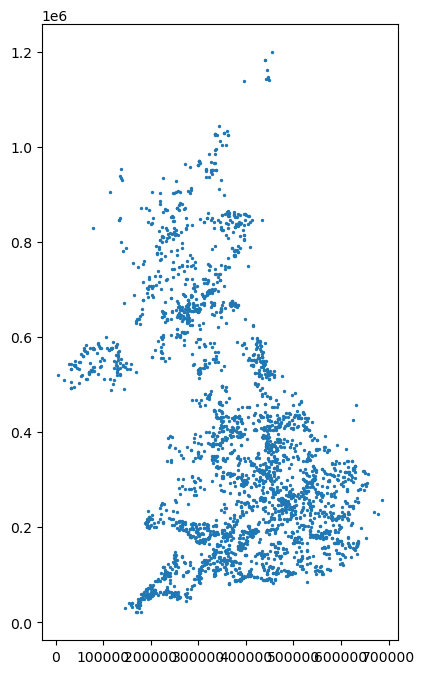

In [229]:
assets_gdf_27700.plot(
    figsize=(8, 8),
    markersize=2
)

## Saving the geospatial asset layer

After creating the GeoDataFrame, I save the cleaned spatial asset layer to the processed data folder.

This makes the workflow reproducible: later notebooks can load the cleaned geospatial dataset directly instead of repeating the raw-data cleaning steps.

In [230]:
processed_path = DATA_PROCESSED / "operational_energy_assets_27700.geojson"

assets_gdf_27700.to_file(processed_path, driver="GeoJSON")

print("Saved to:", processed_path)

Saved to: /Users/oconnor/jaurice-market-notes/projects/physical-climate-risk-uk-energy/data/processed/operational_energy_assets_27700.geojson


In [231]:
saved_check = gpd.read_file(processed_path)

print("Rows:", len(saved_check))
print("CRS:", saved_check.crs)

saved_check.head()

Rows: 3058
CRS: EPSG:27700


,Ref ID,Operator (or Applicant),Site Name,Technology Type,Installed Capacity (MWelec),Development Status,Development Status (short),County,Region,Country,Post Code,X-coordinate,Y-coordinate,Planning Authority,Under Construction,Operational,Solar Site Area (sqm),development_status_clean,geometry
0,3,Scottish and Southern Energy (SSE),Ferrybridge Multifuel 2 (FM2),EfW Incineration,70.00,Operational,Operational,West Yorkshire,Yorkshire and Humber,England,NaN,447490,424684,The Planning Inspectorate - National Infrastru...,01/09/2016,20/12/2019,NaN,operational,POINT (447490 424684)
1,4,Energy Power Resources,Thetford Biomass Power Station,Biomass (dedicated),38.50,Operational,Operational,Norfolk,Eastern,England,NaN,585300,286900,Breckland,NaN,02/10/1998,NaN,operational,POINT (585300 286900)
2,14,Dalkia,Chilton Energy Plant,Biomass (dedicated),18.00,Operational,Operational,County Durham,North East,England,NaN,428049,530414,County Durham,01/03/2010,12/03/2012,NaN,operational,POINT (428049 530414)
3,22,Double H Nurseries,Double H Nurseries Biomass Plant,Biomass (dedicated),1.50,Operational,Operational,Hampshire,South East,England,BH25 5NQ,422804,94625,New Forest,NaN,15/12/2012,NaN,operational,POINT (422804 94625)
4,23,REACT Energy (Kedco),Newry Biomass Phase 1 (Gasification),Advanced Conversion Technologies,2.00,Operational,Operational,Co. Down,Northern Ireland,Northern Ireland,NaN,117392,488885,"Newry, Mourne and Down",NaN,27/06/2012,NaN,operational,POINT (117392 488885)


In [232]:
print("Rows:", len(assets_gdf_27700))
print("CRS:", assets_gdf_27700.crs)
print("Geometry type:", assets_gdf_27700.geometry.geom_type.value_counts())

Rows: 3058
CRS: EPSG:27700
Geometry type: Point    3058
Name: count, dtype: int64


## Why EPSG:27700 is used

The REPD dataset provides `X-coordinate` and `Y-coordinate` values using the British National Grid coordinate system.

This coordinate system is identified in Python as `EPSG:27700`.

A coordinate reference system, or CRS, tells Python how to interpret location values. Without a CRS, the numbers in the coordinate columns are just numbers. With the correct CRS, Python understands that each pair of coordinates represents a real location in Great Britain.

For this project, `EPSG:27700` is useful because it is designed for mapping Great Britain and supports distance calculations in metres.

This matters because later parts of the project may ask questions such as:

- how far an asset is from a boundary,
- whether an asset is near a hazard layer,
- which region an asset belongs to,
- where exposure may be geographically concentrated.

Using the correct CRS is important because distance-based exposure analysis depends on accurate spatial measurement.

In this notebook, I assign `EPSG:27700` when creating the GeoDataFrame so that the renewable energy assets are represented as spatial points in the correct UK coordinate system.